# Optimal Paths on Curved Manifolds (AVBD)

The eikonal demos solve for fronts on flat grids with rich internal metrics. This notebook shows the complementary case: the AVBD solver relaxing a path onto a curved domain. AVBD takes the Euclidean gradient of the path Lagrangian and projects it onto the manifold's tangent space at each vertex, so an off-surface initial guess settles onto the curved geodesic. Rotate the scenes to see the paths hug the surfaces.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. Setup

We use domains where a straight Euclidean line between the endpoints leaves the surface — a paraboloid
bowl and a torus.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from ham.geometry import Euclidean, Paraboloid, Torus
from ham.solvers import AVBDSolver
from ham.vis.style import (use_ham_style, PALETTE, plotly_layout, plotly_surface, plotly_path)

pio.renderers.default = "plotly_mimetype"
use_ham_style()
jax.config.update("jax_enable_x64", False)
key = jax.random.PRNGKey(0)

## 2. Paraboloid: relaxing onto the bowl

The paraboloid is $z = x^2 + y^2$. For two points high on opposite walls, the straight chord floats
above the bowl. AVBD starts from the projected straight line — a slightly kinked guess — and relaxes it
onto the geodesic that dips across the bowl. We read the solver state at increasing iteration budgets to
show the relaxation.

In [2]:
para = Paraboloid()
metric = Euclidean(para)
p0 = para.project(jnp.array([-1.8, -0.5, 0.0]))
p1 = para.project(jnp.array([1.3, 1.6, 0.0]))

budgets = [3, 10, 30, 120, 400]
snapshots = []
for it in budgets:
    snapshots.append(np.array(
        AVBDSolver(step_size=0.02, iterations=it).solve(metric, p0, p1, n_steps=40, key=key).xs))
init_guess = np.array(jax.vmap(para.project)(
    (1 - jnp.linspace(0, 1, 41)[:, None]) * p0 + jnp.linspace(0, 1, 41)[:, None] * p1))
print("final path energy:", float(AVBDSolver(step_size=0.02, iterations=400).solve(
    metric, p0, p1, n_steps=40, key=key).energy))

gx, gy = np.mgrid[-2.2:2.2:60j, -2.2:2.2:60j]
gz = gx**2 + gy**2
gz = np.where(gz > 5.0, np.nan, gz)        # cap the bowl so the path stays prominent
fig = go.Figure()
fig.add_trace(plotly_surface(gx, gy, gz, opacity=0.45))
chord = np.linspace(np.array(p0), np.array(p1), 41)
fig.add_trace(plotly_path(chord, color=PALETTE["rose"], name="straight chord (off-surface)",
                          width=5, dash="dash", show_start=False))
fig.add_trace(plotly_path(init_guess, color=PALETTE["primary"], name="initial guess",
                          width=4, show_start=False))
greys = ["#c4ccd6", "#aab4c0", "#8d99a8"]
for snap, sh in zip(snapshots[:-1][1:], greys):     # intermediate iterations
    fig.add_trace(plotly_path(snap, color=sh, width=3, show_start=False))
fig.add_trace(plotly_path(snapshots[-1], color=PALETTE["accent"], name="AVBD geodesic", width=8))
plotly_layout(fig, "Paraboloid: a kinked guess relaxes onto the geodesic", eye=(1.3, 1.3, 0.8))
fig.show()

final path energy: 0.9351125359535217


## 3. Torus: a domain with mixed curvature

The torus has positive curvature on the outer rim and negative curvature in the inner throat, so its
geodesics are not obvious. The straight chord between two outer-equator points passes through the central
hole; AVBD relaxes onto the surface geodesic.

In [3]:
torus = Torus(major_R=2.0, minor_r=0.8)
tmetric = Euclidean(torus)


def torus_pt(u, v):
    return jnp.array([(torus.R + torus.r * jnp.cos(v)) * jnp.cos(u),
                      (torus.R + torus.r * jnp.cos(v)) * jnp.sin(u),
                      torus.r * jnp.sin(v)])


a = torus_pt(0.4, 0.2)
b = torus_pt(3.4, 0.2)
traj = AVBDSolver(step_size=0.02, iterations=500).solve(tmetric, a, b, n_steps=60, key=key)
T = np.array(traj.xs)
rho = np.sqrt(T[:, 0]**2 + T[:, 1]**2)
print("max distance of path off the torus surface:",
      float(np.max(np.abs(np.sqrt((rho - torus.R)**2 + T[:, 2]**2) - torus.r))))

uu, vv = np.mgrid[0:2*np.pi:90j, 0:2*np.pi:45j]
sx = (torus.R + torus.r * np.cos(vv)) * np.cos(uu)
sy = (torus.R + torus.r * np.cos(vv)) * np.sin(uu)
sz = torus.r * np.sin(vv)
chord = np.linspace(np.array(a), np.array(b), 60)
fig = go.Figure()
fig.add_trace(plotly_surface(sx, sy, sz, opacity=0.5))
fig.add_trace(plotly_path(chord, color=PALETTE["rose"], name="straight chord (through the hole)",
                          width=5, dash="dash", show_start=False))
fig.add_trace(plotly_path(traj.xs, color=PALETTE["accent"], name="AVBD geodesic", width=8))
plotly_layout(fig, "Torus: the geodesic hugs the surface", eye=(1.2, 1.2, 1.6))
fig.show()

max distance of path off the torus surface: 1.7881393432617188e-07


## 4. Convergence

AVBD performs projected block descent on the discrete action, so the path energy decreases until the
discrete Euler–Lagrange residual vanishes. We trace it for both domains.

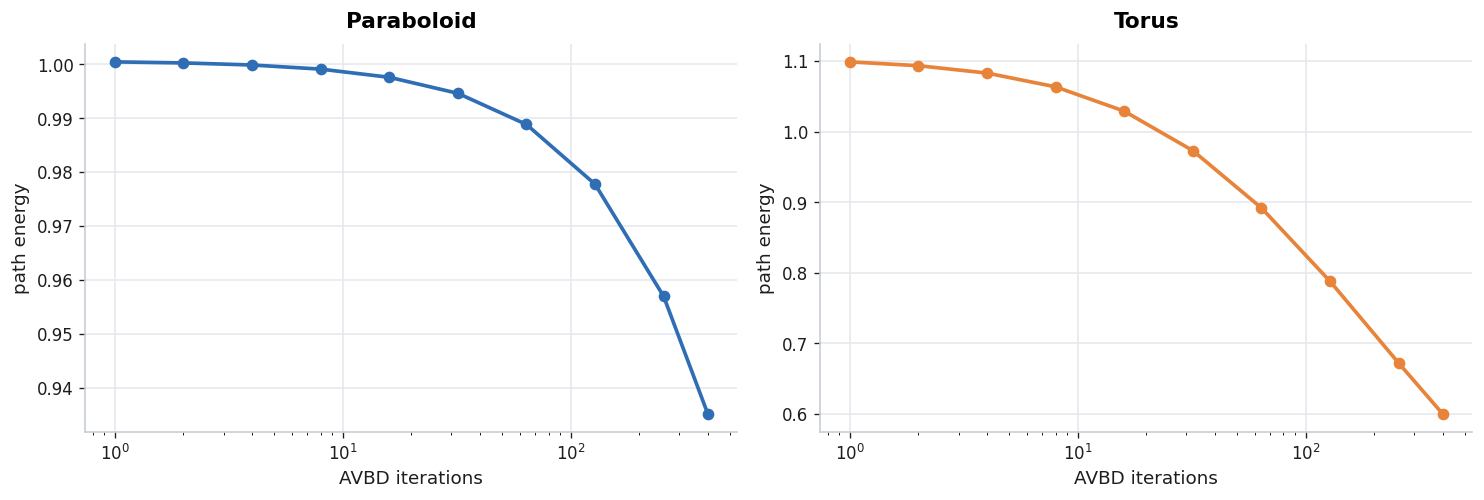

In [4]:
def energy_curve(metric, p, q, n_steps, iters_list, **kw):
    return np.array([float(AVBDSolver(iterations=it, **kw).solve(
        metric, p, q, n_steps=n_steps, key=key).energy) for it in iters_list])


its = [1, 2, 4, 8, 16, 32, 64, 128, 256, 400]
e_para = energy_curve(metric, p0, p1, 40, its, step_size=0.02)
e_tor = energy_curve(tmetric, a, b, 60, its, step_size=0.02)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax[0].plot(its, e_para, "-o", color=PALETTE["primary"])
ax[0].set(title="Paraboloid", xlabel="AVBD iterations", ylabel="path energy", xscale="log")
ax[1].plot(its, e_tor, "-o", color=PALETTE["accent"])
ax[1].set(title="Torus", xlabel="AVBD iterations", ylabel="path energy", xscale="log")
plt.tight_layout(); plt.show()

## 5. Notes

* AVBD needs only `metric.energy` and `manifold.log_map` / `to_tangent`, so it relaxes paths on any
  manifold in the zoo (and your own) without per-surface code.
* The tangent-space projection of the Euclidean gradient is what lets an off-surface guess settle onto
  the intrinsic geodesic.
* Unlike grid-based eikonal solvers (2-D Cartesian), AVBD is dimension- and topology-agnostic — the same
  path drives the high-dimensional latent-space demo.